# E-Commerce Customer Churn — Exploratory Data Analysis
**Group Project | Modeler/Analyst Role**

**Business Problem:** Identify customer segments at the highest risk of churn in an e-commerce platform and recommend actionable interventions to reduce revenue loss.

---
### Notebook Structure
1. Setup & Data Loading
2. Dataset Overview
3. Target Variable Definition
4. Univariate Analysis
5. Churn by Demographics
6. Behavioral Features vs. Churn
7. RFM Feature Deep Dive
8. RFM Customer Segmentation
9. Country × Category Heatmap
10. Correlation & Multicollinearity Check
11. Class Imbalance Check
12. Key EDA Takeaways & Handoff to Modeler
13. Export Processed Dataset

## 1. Setup & Data Loading

In [1]:
!pip install xlrd openpyxl seaborn matplotlib pandas numpy scipy -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

C_TEAL  = '#20808D'
C_RUST  = '#A84B2F'
C_DARK  = '#1B474D'
C_GOLD  = '#FFC553'
C_MAUVE = '#944454'
PALETTE = [C_TEAL, C_RUST, C_DARK, C_GOLD, C_MAUVE, '#848456', '#6E522B']
CHURN_PALETTE = {'Active': C_TEAL, 'Churned': C_RUST, 'Paused': C_GOLD}

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
from google.colab import files
uploaded = files.upload()   # upload cleaned_ecommerce_churn_dataset.xls

import io
filename = list(uploaded.keys())[0]
df_raw = pd.read_excel(io.BytesIO(uploaded[filename]))
print(f'Loaded: {filename}  |  Shape: {df_raw.shape}')

Saving cleaned_ecommerce_churn_dataset.xls to cleaned_ecommerce_churn_dataset.xls
Loaded: cleaned_ecommerce_churn_dataset.xls  |  Shape: (2000, 24)


## 2. Dataset Overview

In [4]:
df = df_raw.copy()

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n')
print('Column Types:')
print(df.dtypes.to_string())
print('\nMissing Values:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values — clean dataset.')
print('\nSample Rows:')
df.head()

Shape: 2,000 rows × 24 columns

Column Types:
order_id                       object
customer_id                    object
age                             int64
product_id                     object
country                        object
signup_date            datetime64[ns]
last_purchase_date     datetime64[ns]
cancellations_count             int64
subscription_status            object
order_date             datetime64[ns]
unit_price                    float64
quantity                        int64
preferred_category             object
product_name                   object
category                       object
gender                         object
order_amount                  float64
recency_days                    int64
frequency                       int64
monetary                      float64
tenure_days                     int64
avg_order_value               float64
purchase_intensity            float64
inactivity_ratio              float64

Missing Values:
No missing values — clean

,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,...,category,gender,order_amount,recency_days,frequency,monetary,tenure_days,avg_order_value,purchase_intensity,inactivity_ratio
0,ORD5000,CUST1000,39,PROD200,Canada,2021-01-07,2023-02-21,0,active,2024-08-20,...,Sports,Female,391.05,912,37,391.05,1687,10.568919,0.021932,0.540605
1,ORD5001,CUST1001,61,PROD201,USA,2020-10-19,2021-12-08,0,active,2025-07-17,...,Home,Female,512.16,1352,35,512.16,1767,14.633143,0.019808,0.765139
2,ORD5002,CUST1002,26,PROD202,Pakistan,2023-06-10,2023-09-04,3,cancelled,2025-03-12,...,Clothing,Female,1208.28,717,44,1208.28,803,27.460909,0.054795,0.892902
3,ORD5003,CUST1003,54,PROD203,India,2023-07-30,2024-02-20,4,paused,2024-09-19,...,Beauty,Male,338.64,548,1,338.64,753,338.640000,0.001328,0.727756
4,ORD5004,CUST1004,50,PROD204,India,2020-12-09,2024-09-14,0,active,2024-08-08,...,Electronics,Male,438.62,341,35,438.62,1716,12.532000,0.020396,0.198718


In [5]:
print('Numeric Summary:')
df.describe().round(2)

Numeric Summary:


,age,signup_date,last_purchase_date,cancellations_count,order_date,unit_price,quantity,order_amount,recency_days,frequency,monetary,tenure_days,avg_order_value,purchase_intensity,inactivity_ratio
count,2000.00,2000,2000,2000.00,2000,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,44.08,2022-02-11 01:17:02.400000,2023-11-28 18:36:00,2.44,2023-11-19 15:34:33.600000,324.72,4.95,1025.85,631.22,25.16,1025.85,1286.95,89.45,0.02,0.49
min,18.00,2020-08-20 00:00:00,2020-09-20 00:00:00,0.00,2020-09-18 00:00:00,2.85,1.00,22.29,1.00,1.00,22.29,732.00,0.48,0.00,0.00
25%,31.00,2021-05-15 18:00:00,2023-02-26 00:00:00,1.00,2023-02-17 18:00:00,111.13,3.00,551.94,285.00,13.00,551.94,1017.00,21.47,0.01,0.24
50%,45.00,2022-01-29 00:00:00,2024-01-13 00:00:00,2.00,2024-01-03 00:00:00,206.52,5.00,1057.23,586.00,25.00,1057.23,1300.00,40.04,0.02,0.48
75%,57.00,2022-11-08 00:00:00,2024-11-09 00:00:00,4.00,2024-10-17 06:00:00,384.51,7.00,1494.68,907.00,37.00,1494.68,1558.25,81.68,0.03,0.74
max,69.00,2023-08-20 00:00:00,2025-08-20 00:00:00,5.00,2025-08-20 00:00:00,1991.63,9.00,1998.08,1796.00,49.00,1998.08,1827.00,1994.70,0.07,1.00
std,14.80,NaN,NaN,1.70,NaN,361.55,2.56,560.79,410.96,14.16,560.79,313.31,178.78,0.01,0.29


## 3. Target Variable Definition

The dataset has no explicit `Churn` binary column. We derive it from `subscription_status`:

| subscription_status | Label | Rationale |
|---|---|---|
| `active` | **Active (0)** | Currently engaged customer |
| `cancelled` | **Churned (1)** | Hard churn — subscription ended |
| `paused` | **Paused (at-risk)** | Soft churn — noted separately, not included in binary target |

> **Decision:** `Churn = 1` if `subscription_status == 'cancelled'` (hard churn). It is clearer for modeling. Paused customers are tracked separately as an at-risk group. (soft churn)

In [8]:
df['churn'] = (df['subscription_status'] == 'cancelled').astype(int)
status_map = {'active': 'Active', 'cancelled': 'Churned', 'paused': 'Paused'}
df['churn_label'] = df['subscription_status'].map(status_map)

print('Subscription status distribution:')
counts = df['subscription_status'].value_counts()
for status, n in counts.items():
    print(f'  {status:<12} {n:>5}  ({n/len(df)*100:.1f}%)')

print(f'\nBinary churn rate (cancelled only): {df["churn"].mean()*100:.1f}%')
print(f'  Churned (1): {df["churn"].sum():,}')
print(f'  Active  (0): {(df["churn"]==0).sum():,}  (includes {(df["subscription_status"]=="paused").sum()} paused)')

Subscription status distribution:
  active        1204  (60.2%)
  cancelled      493  (24.6%)
  paused         303  (15.2%)

Binary churn rate (cancelled only): 24.6%
  Churned (1): 493
  Active  (0): 1,507  (includes 303 paused)


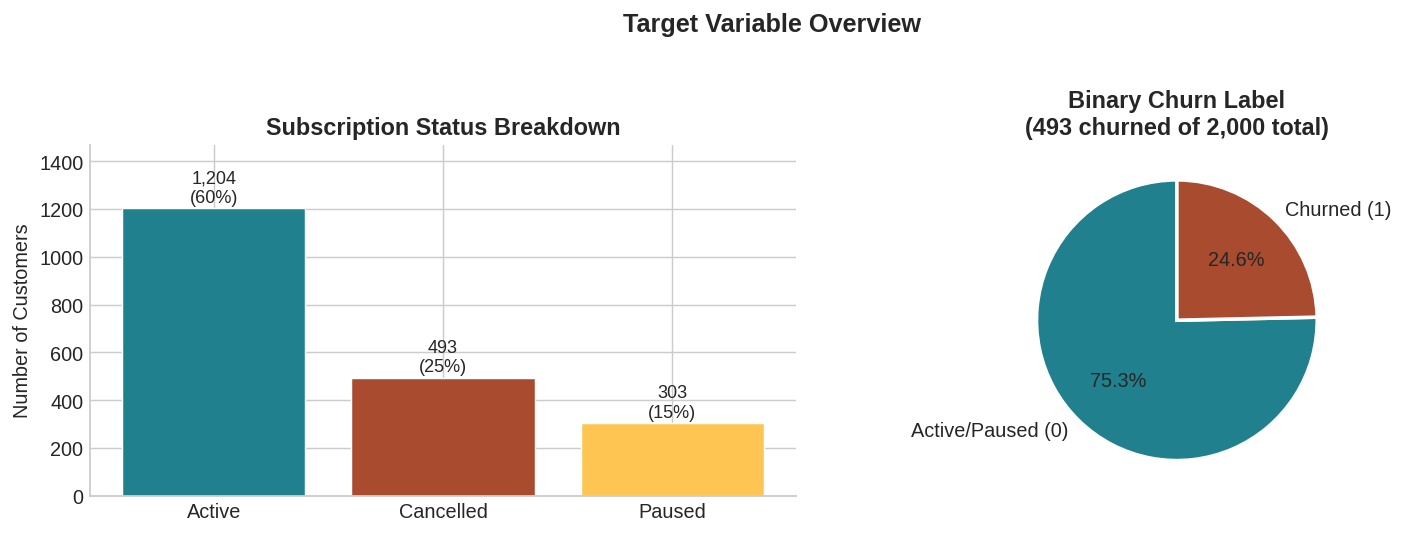

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: 3-way status
ax = axes[0]
order = ['active', 'cancelled', 'paused']
colors_3 = [C_TEAL, C_RUST, C_GOLD]
vals = [df['subscription_status'].value_counts()[s] for s in order]
bars = ax.bar(['Active', 'Cancelled', 'Paused'], vals, color=colors_3, edgecolor='white', linewidth=0.8)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{v:,}\n({v/len(df)*100:.0f}%)', ha='center', va='bottom', fontsize=10)
ax.set_title('Subscription Status Breakdown')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, max(vals) * 1.22)

# Right: binary churn pie
ax2 = axes[1]
churn_counts = df['churn'].value_counts().sort_index()
ax2.pie(churn_counts.values,
        labels=['Active/Paused (0)', 'Churned (1)'],
        autopct='%1.1f%%',
        colors=[C_TEAL, C_RUST],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        textprops={'fontsize': 11})
ax2.set_title(f'Binary Churn Label\n({df["churn"].sum():,} churned of {len(df):,} total)')

plt.suptitle('Target Variable Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Univariate Analysis
How the main customer metrics are distributed.

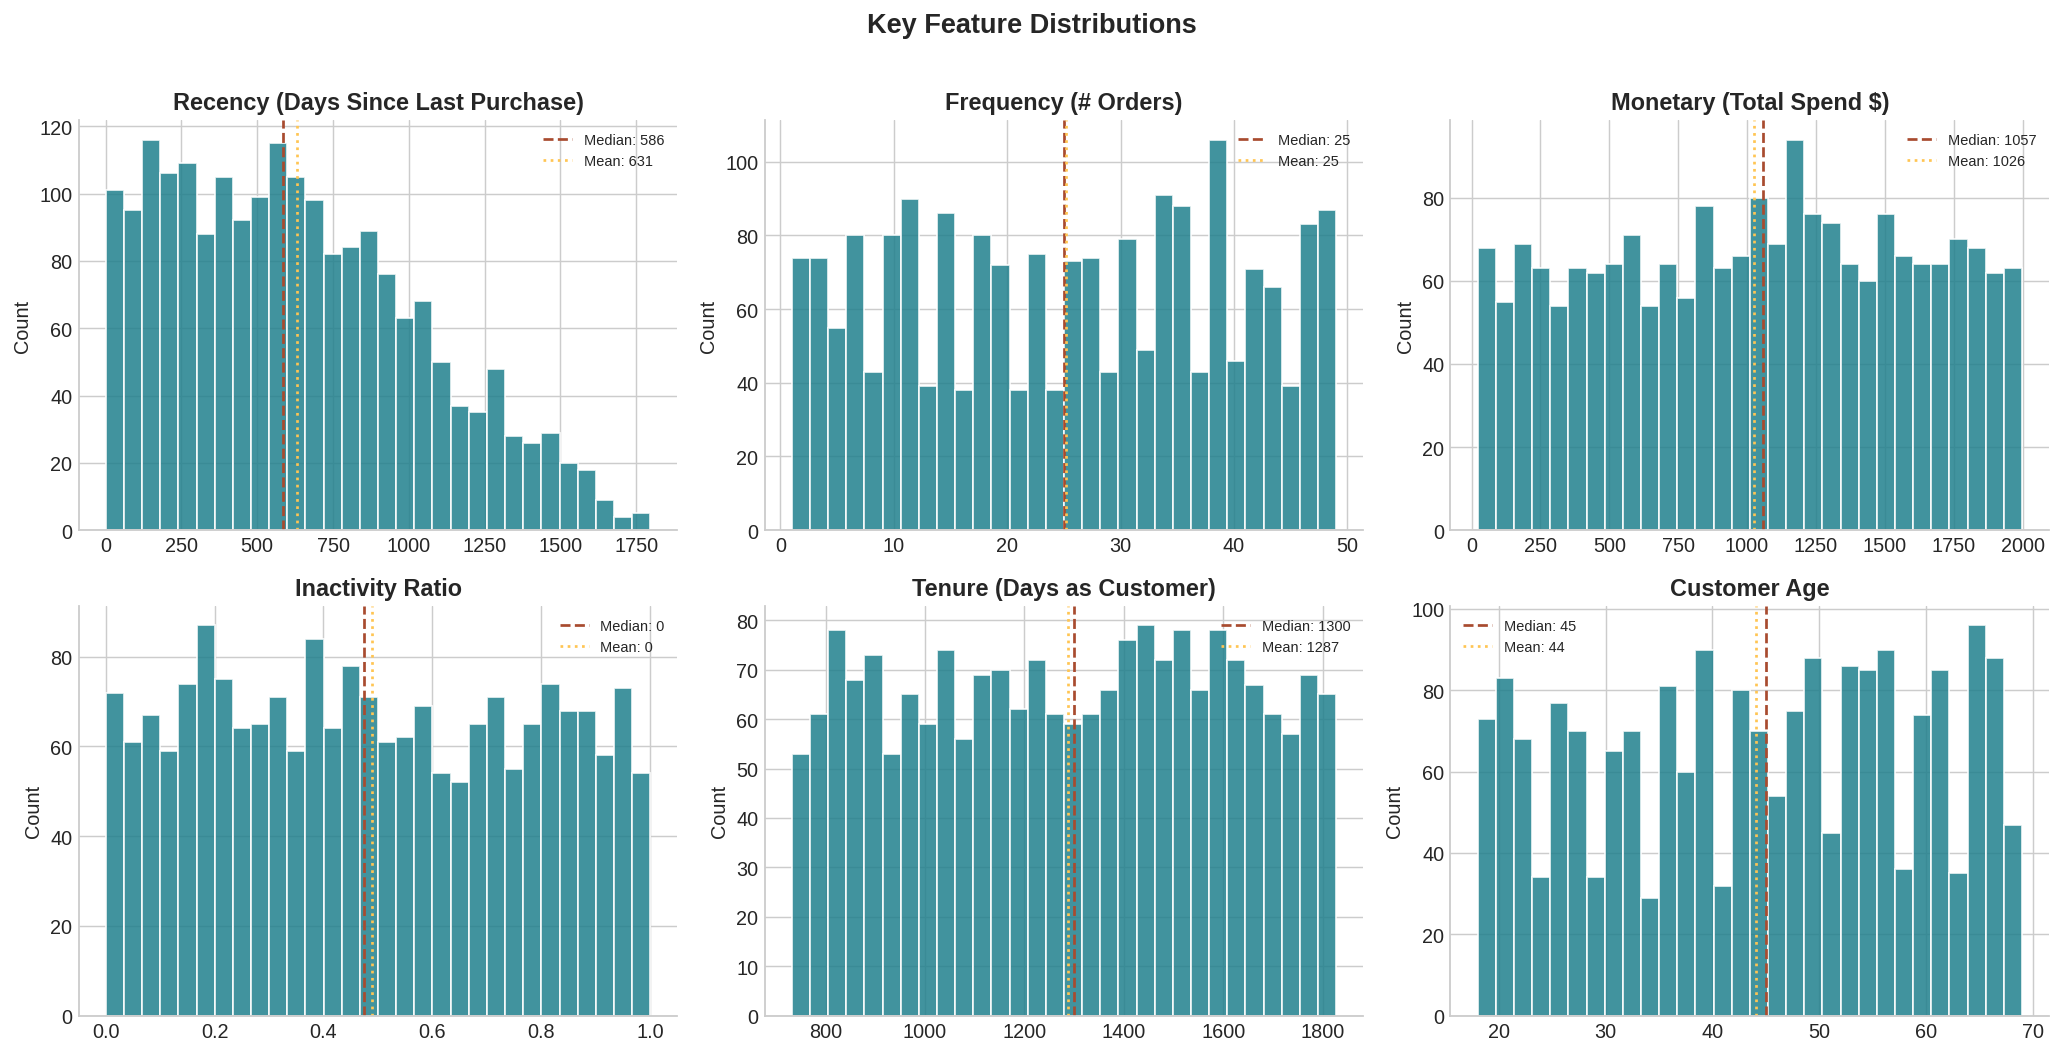

In [10]:
key_numeric = [
    ('recency_days',     'Recency (Days Since Last Purchase)'),
    ('frequency',        'Frequency (# Orders)'),
    ('monetary',         'Monetary (Total Spend $)'),
    ('inactivity_ratio', 'Inactivity Ratio'),
    ('tenure_days',      'Tenure (Days as Customer)'),
    ('age',              'Customer Age'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(key_numeric):
    ax = axes[i]
    ax.hist(df[col].dropna(), bins=30, color=C_TEAL, edgecolor='white', alpha=0.85)
    median_val = df[col].median()
    mean_val   = df[col].mean()
    ax.axvline(median_val, color=C_RUST,  linestyle='--', linewidth=1.5, label=f'Median: {median_val:.0f}')
    ax.axvline(mean_val,   color=C_GOLD, linestyle=':',  linewidth=1.5, label=f'Mean: {mean_val:.0f}')
    ax.set_title(label)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Key Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

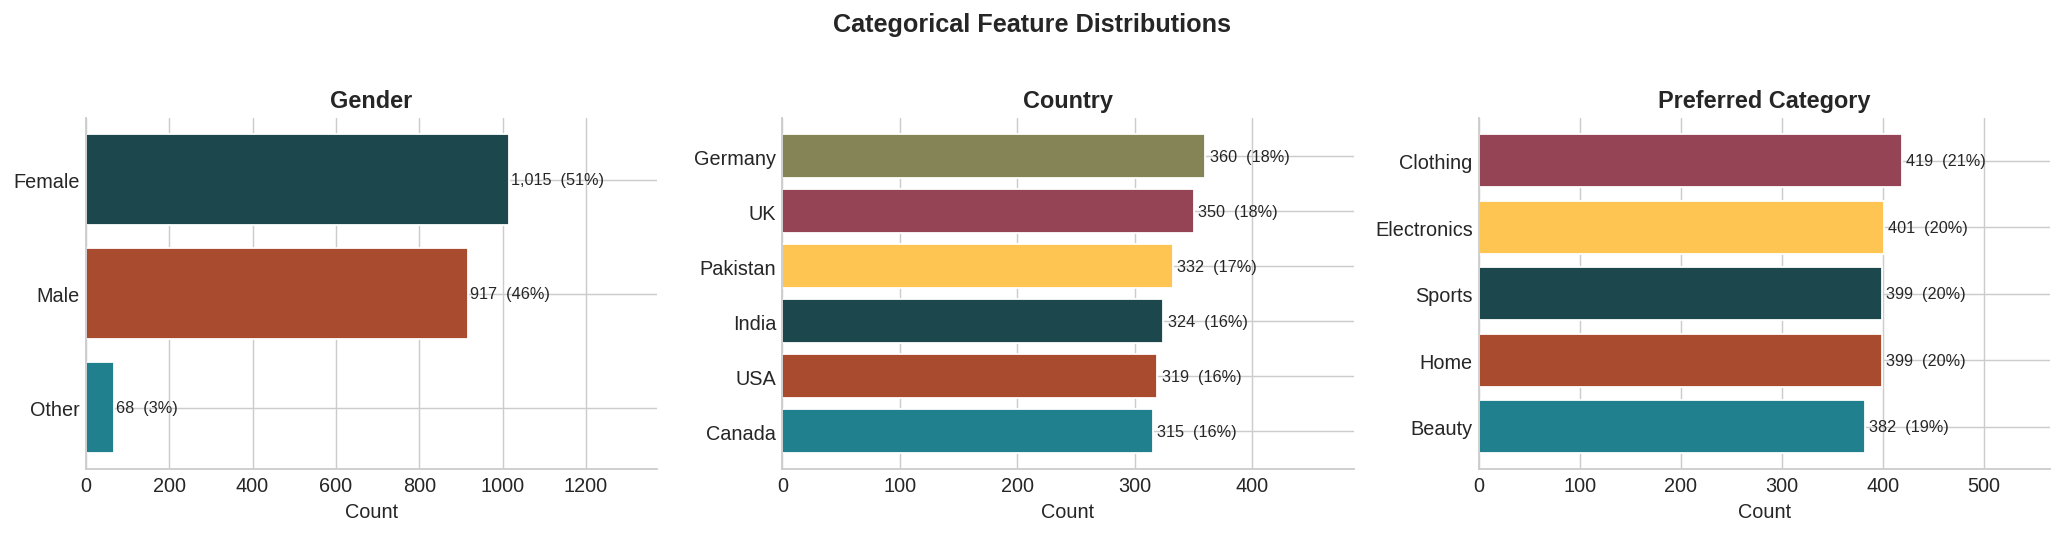

In [17]:
cat_cols = [('gender', 'Gender'), ('country', 'Country'),
            ('preferred_category', 'Preferred Category')]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (col, label) in zip(axes, cat_cols):
    vc = df[col].value_counts()
    bars = ax.barh(vc.index[::-1], vc.values[::-1],
                   color=PALETTE[:len(vc)], edgecolor='white')
    for bar, v in zip(bars, vc.values[::-1]):
        ax.text(bar.get_width() + 4, bar.get_y() + bar.get_height()/2,
                f'{v:,}  ({v/len(df)*100:.0f}%)', va='center', fontsize=9)
    ax.set_title(label)
    ax.set_xlabel('Count')
    ax.set_xlim(0, vc.max() * 1.35)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Churn by Demographics
Comparing churn rates across gender, country, and age group.

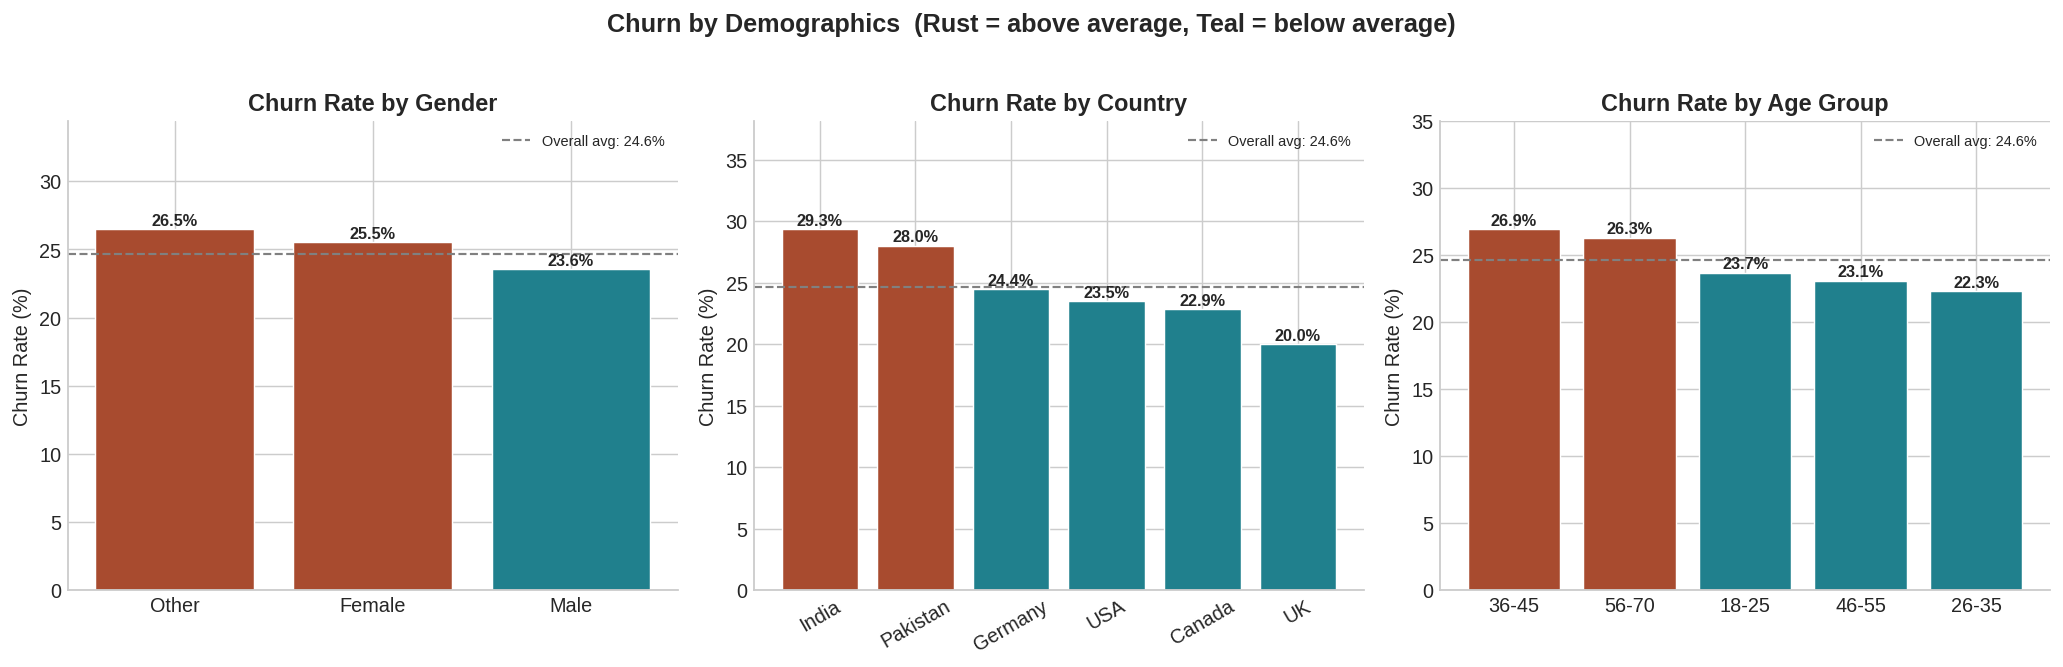

In [12]:
df['age_group'] = pd.cut(df['age'],
                          bins=[17, 25, 35, 45, 55, 70],
                          labels=['18-25', '26-35', '36-45', '46-55', '56-70'])

avg_churn = df['churn'].mean() * 100

def plot_churn_bar(col, ax, title, rotate=False):
    rates = df.groupby(col, observed=True)['churn'].mean().sort_values(ascending=False) * 100
    colors = [C_RUST if v >= avg_churn else C_TEAL for v in rates.values]
    bars = ax.bar(rates.index.astype(str), rates.values,
                  color=colors, edgecolor='white', linewidth=0.8)
    ax.axhline(avg_churn, color='grey', linestyle='--', linewidth=1.2,
               label=f'Overall avg: {avg_churn:.1f}%')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(title)
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, rates.max() * 1.3)
    ax.legend(fontsize=8)
    if rotate:
        ax.tick_params(axis='x', rotation=30)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_churn_bar('gender',    axes[0], 'Churn Rate by Gender')
plot_churn_bar('country',   axes[1], 'Churn Rate by Country', rotate=True)
plot_churn_bar('age_group', axes[2], 'Churn Rate by Age Group')

plt.suptitle('Churn by Demographics  (Rust = above average, Teal = below average)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Behavioral Features vs. Churn
### 6a. Churn Rate by Preferred Category

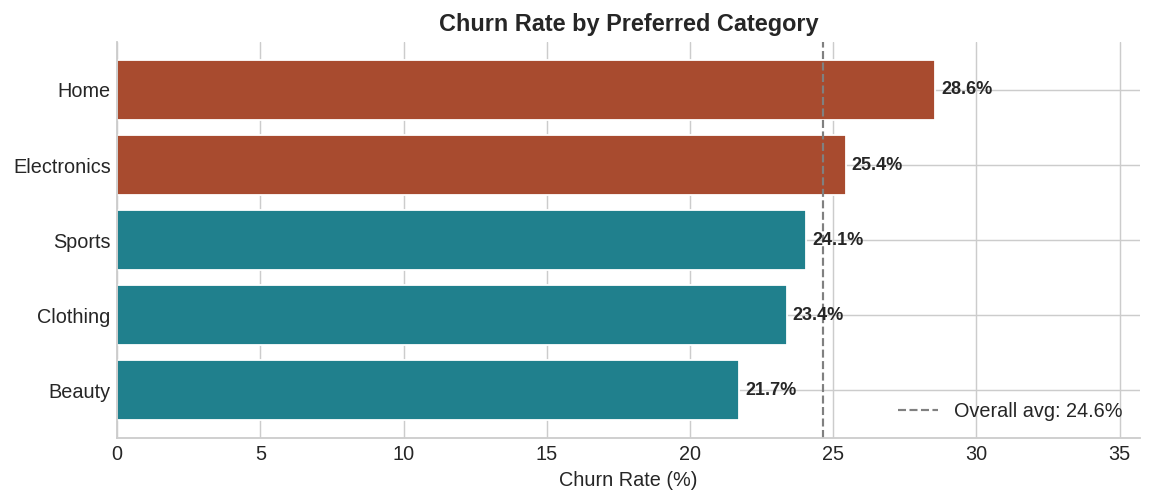

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))

rates = df.groupby('preferred_category')['churn'].mean().sort_values(ascending=True) * 100
colors = [C_RUST if v >= avg_churn else C_TEAL for v in rates.values]
bars = ax.barh(rates.index, rates.values, color=colors, edgecolor='white')
for bar, v in zip(bars, rates.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.axvline(avg_churn, color='grey', linestyle='--', linewidth=1.2,
           label=f'Overall avg: {avg_churn:.1f}%')
ax.set_xlabel('Churn Rate (%)')
ax.set_title('Churn Rate by Preferred Category')
ax.set_xlim(0, rates.max() * 1.25)
ax.legend()
plt.tight_layout()
plt.show()

### 6b. Behavioral Feature Distributions and Statistical Significance

The violin plots above visualize the distributions of key behavioral features for both 'Active' and 'Churned' customers. The `p` value and significance indicators (`*`, `**`, `***`, `ns`) below each plot denote the results of a Mann-Whitney U test, which assesses whether there is a statistically significant difference between the distributions of that feature for the two customer groups (Active vs. Churned).

*   `p < 0.05`: Indicates a statistically significant difference.
*   `ns` (not significant): Indicates no statistically significant difference (p >= 0.05).

**Key Observation:**

Notably, for **all behavioral features** examined (Recency, Frequency, Monetary, Inactivity Ratio, Tenure, Avg Order Value, Cancellations Count, and Age), the Mann-Whitney U test returned a `p > 0.05` (marked as `ns`). This means that, based on this non-parametric statistical test, we **do not find statistically significant differences** in the distributions of these features between active and churned customers in this dataset.

**Implications:**

*   While there might be visual differences in the violin plots, the statistical test suggests that these observed differences could be due to random chance rather than a true underlying difference between the groups.
*   This finding is crucial for the subsequent modeling phase. It suggests that these individual behavioral features, when considered in isolation, may not be strong standalone predictors for differentiating between active and churned customers. Modelers should be aware of this and might need to explore feature engineering, interaction terms, or more complex models to capture subtle patterns if these features are still deemed conceptually important.

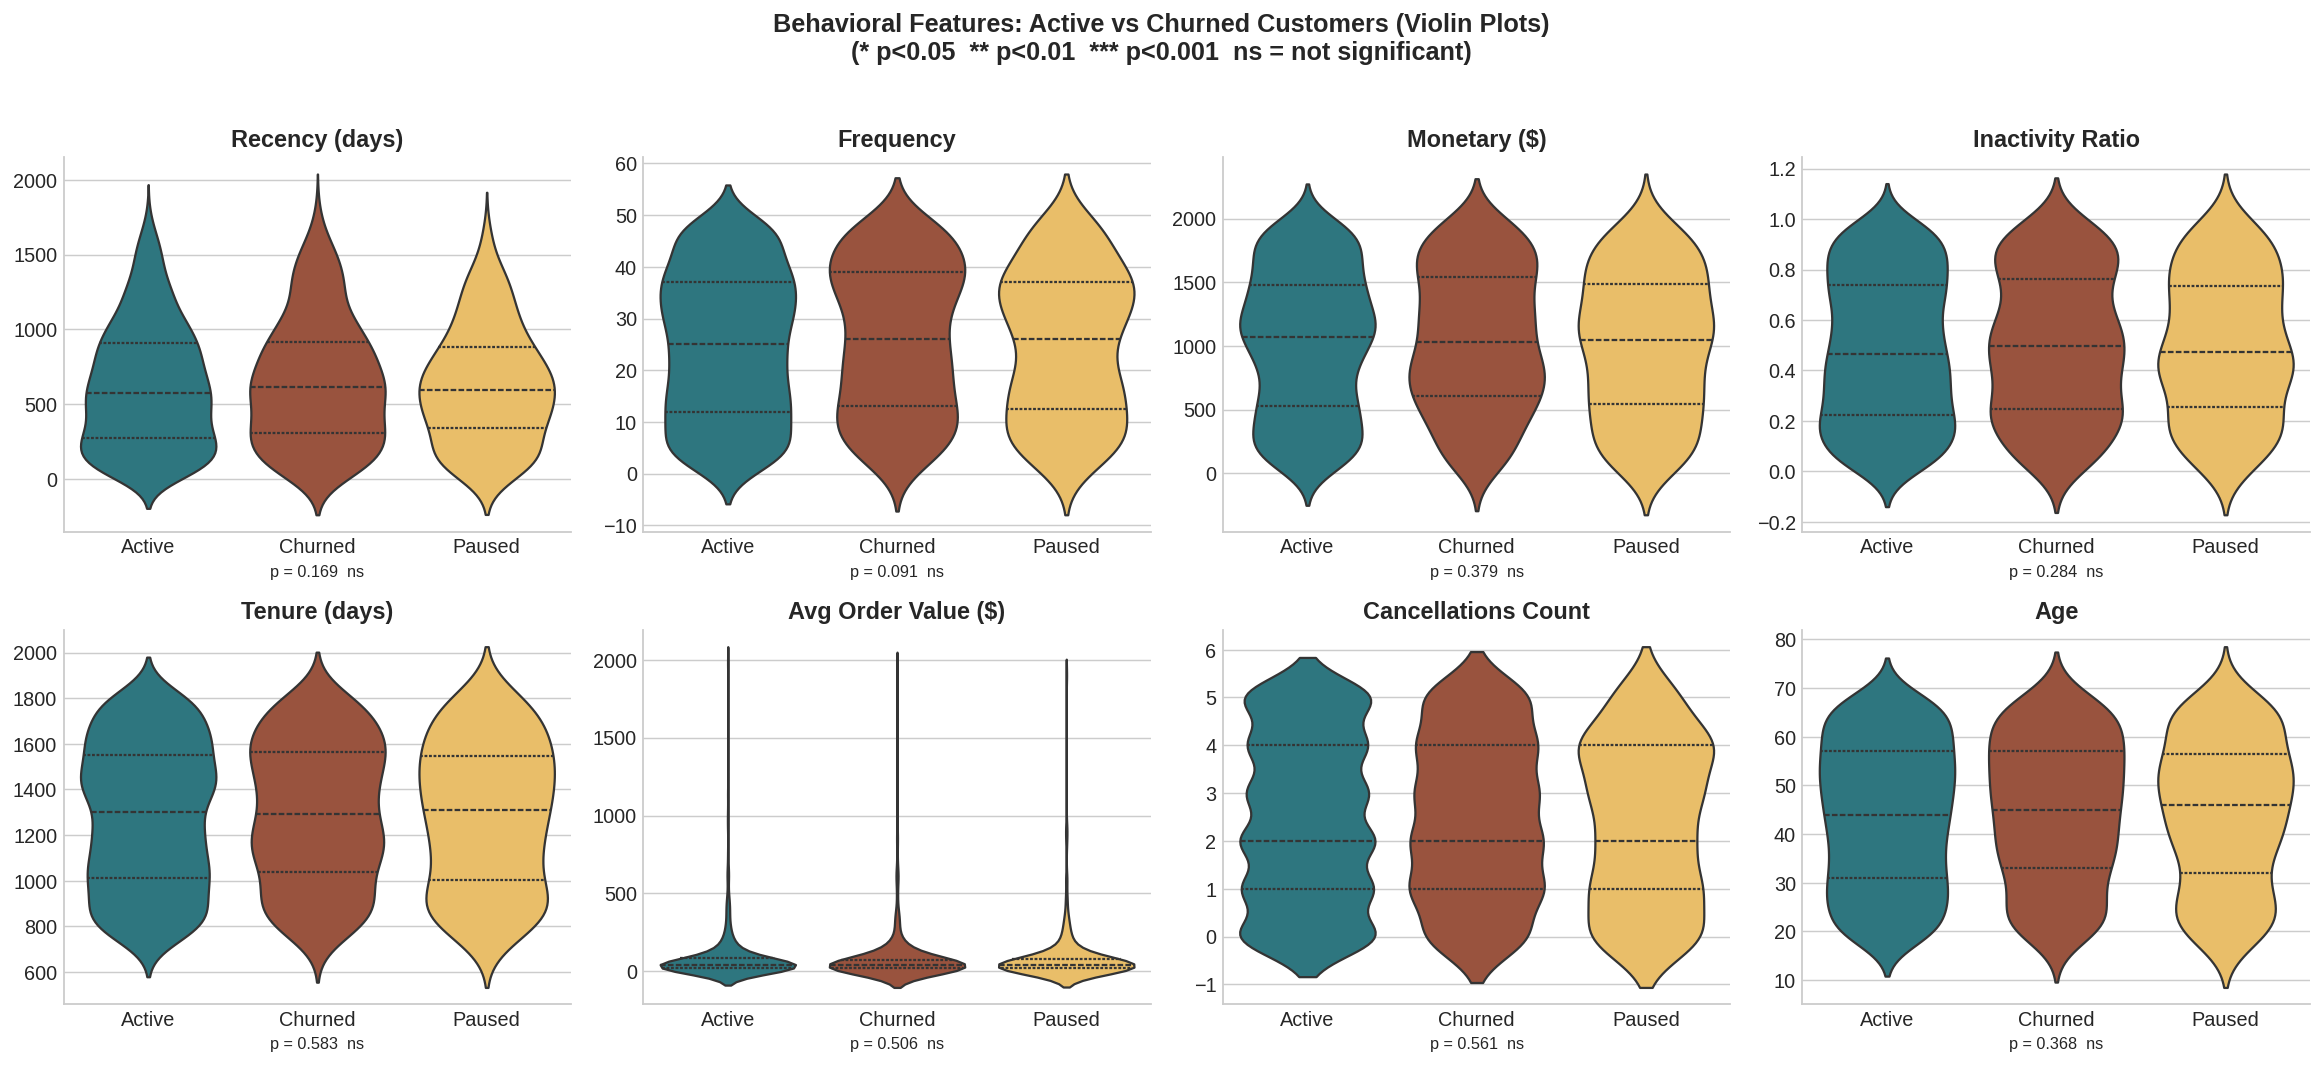

In [18]:
box_features = [
    ('recency_days',       'Recency (days)'),
    ('frequency',          'Frequency'),
    ('monetary',           'Monetary ($)'),
    ('inactivity_ratio',   'Inactivity Ratio'),
    ('tenure_days',        'Tenure (days)'),
    ('avg_order_value',    'Avg Order Value ($)'),
    ('cancellations_count','Cancellations Count'),
    ('age',                'Age'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(box_features):
    ax = axes[i]
    data_active  = df[df['churn']==0][col].dropna()
    data_churned = df[df['churn']==1][col].dropna()

    sns.violinplot(x='churn_label', y=col, data=df, ax=ax,
                   palette=CHURN_PALETTE, inner='quartile')

    _, p = stats.mannwhitneyu(data_active, data_churned, alternative='two-sided')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ax.set_title(label)
    ax.set_xlabel(f'p = {p:.3f}  {sig}', fontsize=9)
    ax.set_ylabel('') # Remove y-label to avoid clutter, title explains the feature

plt.suptitle('Behavioral Features: Active vs Churned Customers (Violin Plots)\n'
             '(* p<0.05  ** p<0.01  *** p<0.001  ns = not significant)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. RFM Feature Breakdown

Grouping recency, inactivity, and tenure into ranges to spot which customer groups churn the most.

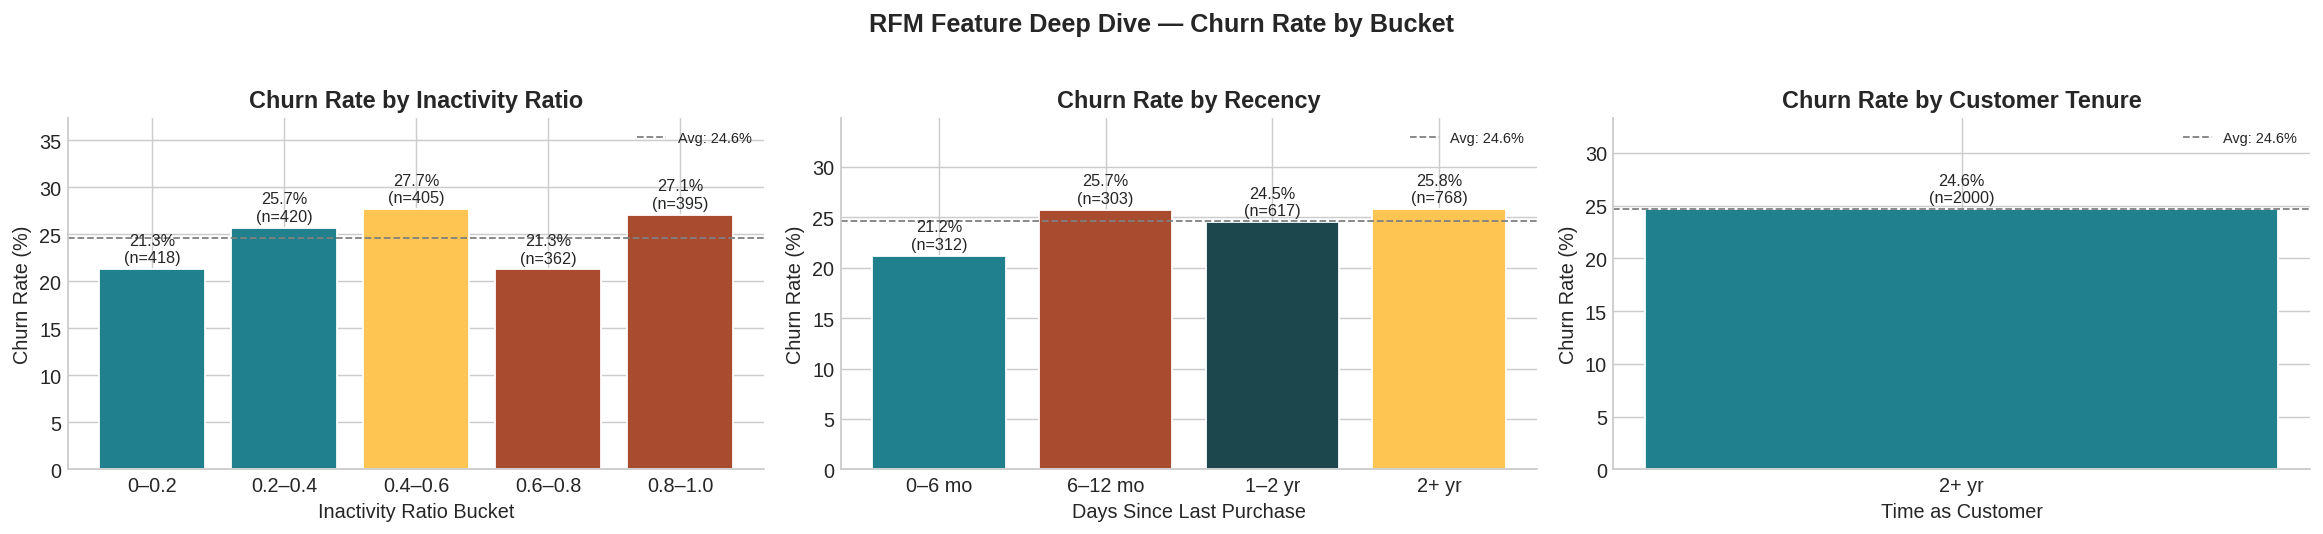

In [19]:
df['inactivity_bin'] = pd.cut(df['inactivity_ratio'],
                               bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                               labels=['0–0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0'])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Inactivity ratio
inact_churn = df.groupby('inactivity_bin', observed=True)['churn'].mean() * 100
inact_count = df.groupby('inactivity_bin', observed=True)['churn'].count()
ax = axes[0]
bars = ax.bar(inact_churn.index, inact_churn.values,
              color=[C_TEAL, C_TEAL, C_GOLD, C_RUST, C_RUST], edgecolor='white')
for bar, v, n in zip(bars, inact_churn.values, inact_count.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{v:.1f}%\n(n={n})', ha='center', va='bottom', fontsize=9)
ax.axhline(avg_churn, color='grey', linestyle='--', linewidth=1, label=f'Avg: {avg_churn:.1f}%')
ax.set_title('Churn Rate by Inactivity Ratio')
ax.set_xlabel('Inactivity Ratio Bucket')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, inact_churn.max() * 1.35)
ax.legend(fontsize=8)

# Recency bins
df['recency_bin'] = pd.cut(df['recency_days'],
                            bins=[0, 180, 360, 720, 1800],
                            labels=['0–6 mo', '6–12 mo', '1–2 yr', '2+ yr'])
rec_churn = df.groupby('recency_bin', observed=True)['churn'].mean() * 100
rec_count = df.groupby('recency_bin', observed=True)['churn'].count()
ax2 = axes[1]
bars2 = ax2.bar(rec_churn.index, rec_churn.values,
                color=PALETTE[:4], edgecolor='white')
for bar, v, n in zip(bars2, rec_churn.values, rec_count.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
             f'{v:.1f}%\n(n={n})', ha='center', va='bottom', fontsize=9)
ax2.axhline(avg_churn, color='grey', linestyle='--', linewidth=1, label=f'Avg: {avg_churn:.1f}%')
ax2.set_title('Churn Rate by Recency')
ax2.set_xlabel('Days Since Last Purchase')
ax2.set_ylabel('Churn Rate (%)')
ax2.set_ylim(0, rec_churn.max() * 1.35)
ax2.legend(fontsize=8)

# Tenure bins
df['tenure_bin'] = pd.cut(df['tenure_days'],
                           bins=[0, 180, 365, 730, 3000],
                           labels=['<6 mo', '6–12 mo', '1–2 yr', '2+ yr'])
ten_churn = df.groupby('tenure_bin', observed=True)['churn'].mean() * 100
ten_count = df.groupby('tenure_bin', observed=True)['churn'].count()
ax3 = axes[2]
bars3 = ax3.bar(ten_churn.index, ten_churn.values,
                color=PALETTE[:4], edgecolor='white')
for bar, v, n in zip(bars3, ten_churn.values, ten_count.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
             f'{v:.1f}%\n(n={n})', ha='center', va='bottom', fontsize=9)
ax3.axhline(avg_churn, color='grey', linestyle='--', linewidth=1, label=f'Avg: {avg_churn:.1f}%')
ax3.set_title('Churn Rate by Customer Tenure')
ax3.set_xlabel('Time as Customer')
ax3.set_ylabel('Churn Rate (%)')
ax3.set_ylim(0, ten_churn.max() * 1.35)
ax3.legend(fontsize=8)

plt.suptitle('RFM Feature Deep Dive — Churn Rate by Bucket',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. RFM Customer Segmentation
Scoring customers on Recency, Frequency, and Monetary value (1–4 each) and grouping into actionable business segments.

In [21]:
df['R_score'] = pd.qcut(df['recency_days'], q=4, labels=[4, 3, 2, 1]).astype(int)
df['F_score'] = pd.qcut(df['frequency'],    q=4, labels=[1, 2, 3, 4]).astype(int)
df['M_score'] = pd.qcut(df['monetary'],      q=4, labels=[1, 2, 3, 4]).astype(int)
df['RFM_score'] = df['R_score'] + df['F_score'] + df['M_score']

def rfm_segment(row):
    s = row['RFM_score']
    if s >= 10:  return 'Champions'
    elif s >= 8: return 'Loyal Customers'
    elif s >= 6: return 'Potential Loyalists'
    elif s >= 4: return 'At Risk'
    else:        return 'Lost'

df['rfm_segment'] = df.apply(rfm_segment, axis=1)

seg_order  = ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk', 'Lost']
seg_counts = df['rfm_segment'].value_counts()
seg_churn  = df.groupby('rfm_segment')['churn'].mean() * 100

print('RFM Segment Summary:')
for seg in seg_order:
    n  = seg_counts.get(seg, 0)
    cr = seg_churn.get(seg, 0)
    print(f'  {seg:<22}  n={n:>4}   Churn rate = {cr:.1f}%')

RFM Segment Summary:
  Champions               n= 320   Churn rate = 27.8%
  Loyal Customers         n= 676   Churn rate = 21.9%
  Potential Loyalists     n= 680   Churn rate = 27.4%
  At Risk                 n= 293   Churn rate = 21.5%
  Lost                    n=  31   Churn rate = 22.6%


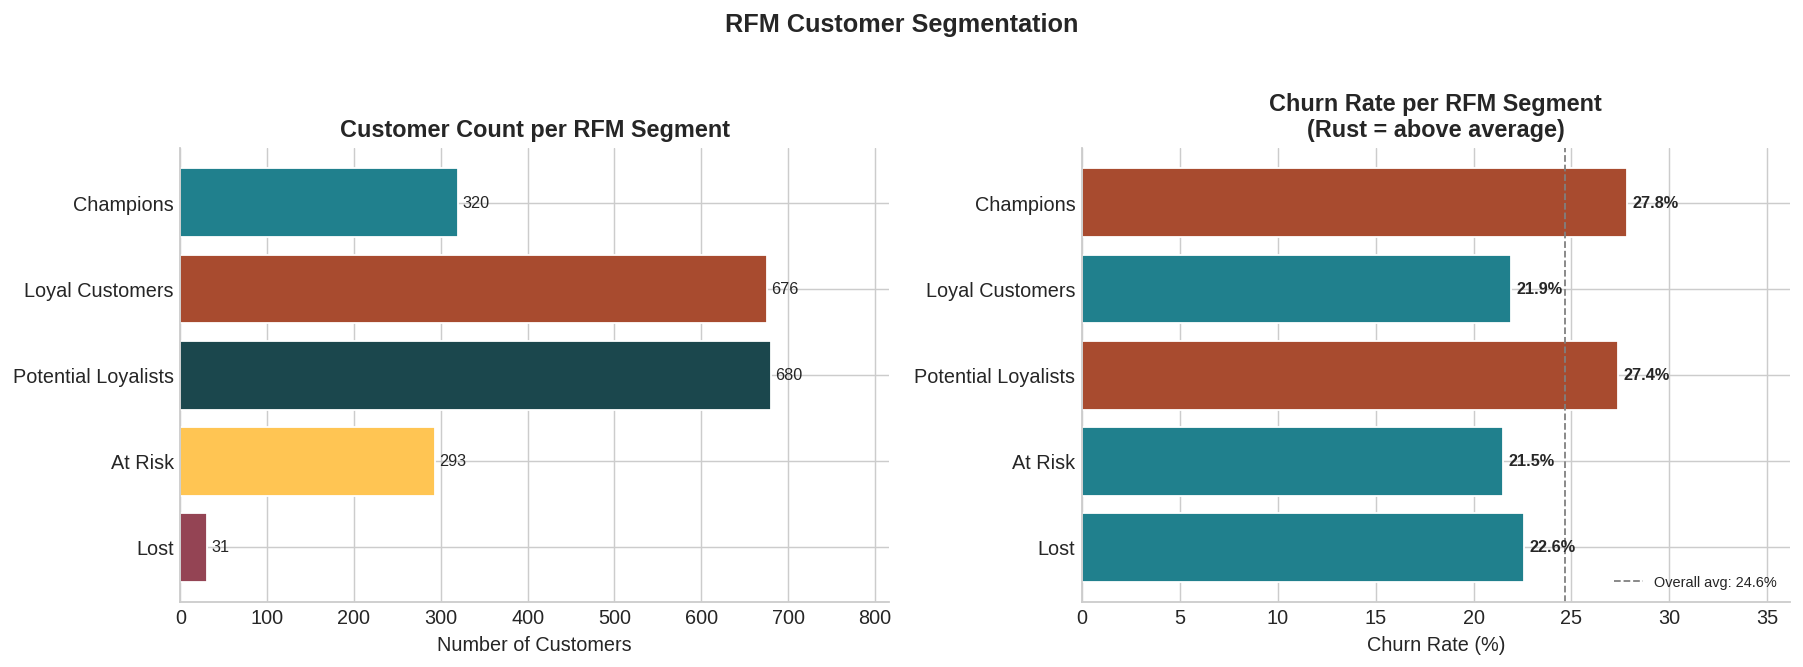

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: segment sizes
ax = axes[0]
counts_ordered = [seg_counts.get(s, 0) for s in seg_order]
bars = ax.barh(seg_order[::-1], counts_ordered[::-1],
               color=PALETTE[:5][::-1], edgecolor='white')
for bar, v in zip(bars, counts_ordered[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{v:,}', va='center', fontsize=9)
ax.set_title('Customer Count per RFM Segment')
ax.set_xlabel('Number of Customers')
ax.set_xlim(0, max(counts_ordered) * 1.2)

# Right: churn rate per segment
ax2 = axes[1]
churn_ordered = [seg_churn.get(s, 0) for s in seg_order]
bar_colors2 = [C_RUST if v >= avg_churn else C_TEAL for v in churn_ordered]
bars2 = ax2.barh(seg_order[::-1], churn_ordered[::-1],
                 color=bar_colors2[::-1], edgecolor='white')
for bar, v in zip(bars2, churn_ordered[::-1]):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')
ax2.axvline(avg_churn, color='grey', linestyle='--', linewidth=1,
            label=f'Overall avg: {avg_churn:.1f}%')
ax2.set_title('Churn Rate per RFM Segment\n(Rust = above average)')
ax2.set_xlabel('Churn Rate (%)')
ax2.set_xlim(0, max(churn_ordered) * 1.3 if max(churn_ordered) > 0 else 50)
ax2.legend(fontsize=8)

plt.suptitle('RFM Customer Segmentation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Country × Category Heatmap
Cross-segment view: which country–category combinations have the highest churn?

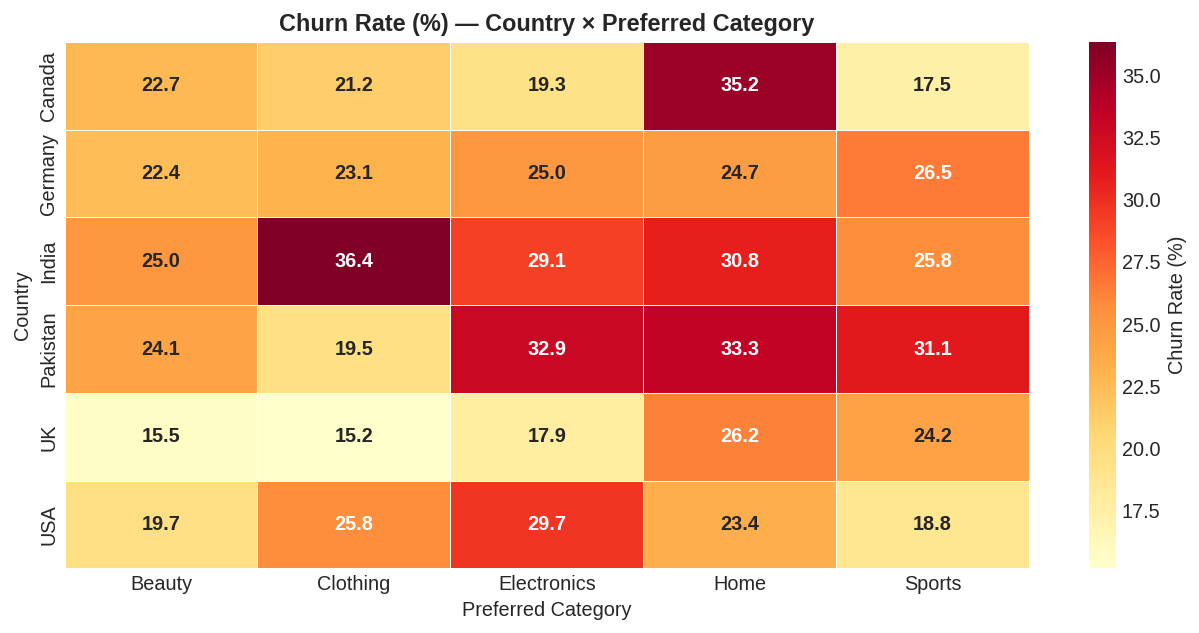

Top 5 highest-risk Country × Category combos:
 Country    Category  Churn Rate (%)
   India    Clothing       36.363636
  Canada        Home       35.185185
Pakistan        Home       33.333333
Pakistan Electronics       32.876712
Pakistan      Sports       31.147541


In [23]:
pivot = df.pivot_table(values='churn', index='country',
                        columns='preferred_category', aggfunc='mean') * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'},
            cbar_kws={'label': 'Churn Rate (%)'})
ax.set_title('Churn Rate (%) — Country × Preferred Category',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Preferred Category')
ax.set_ylabel('Country')
plt.tight_layout()
plt.show()

# Flag highest-risk combos
flat = pivot.stack().reset_index()
flat.columns = ['Country', 'Category', 'Churn Rate (%)']
print('Top 5 highest-risk Country × Category combos:')
print(flat.sort_values('Churn Rate (%)', ascending=False).head(5).to_string(index=False))

## 10. Correlation & Multicollinearity Check

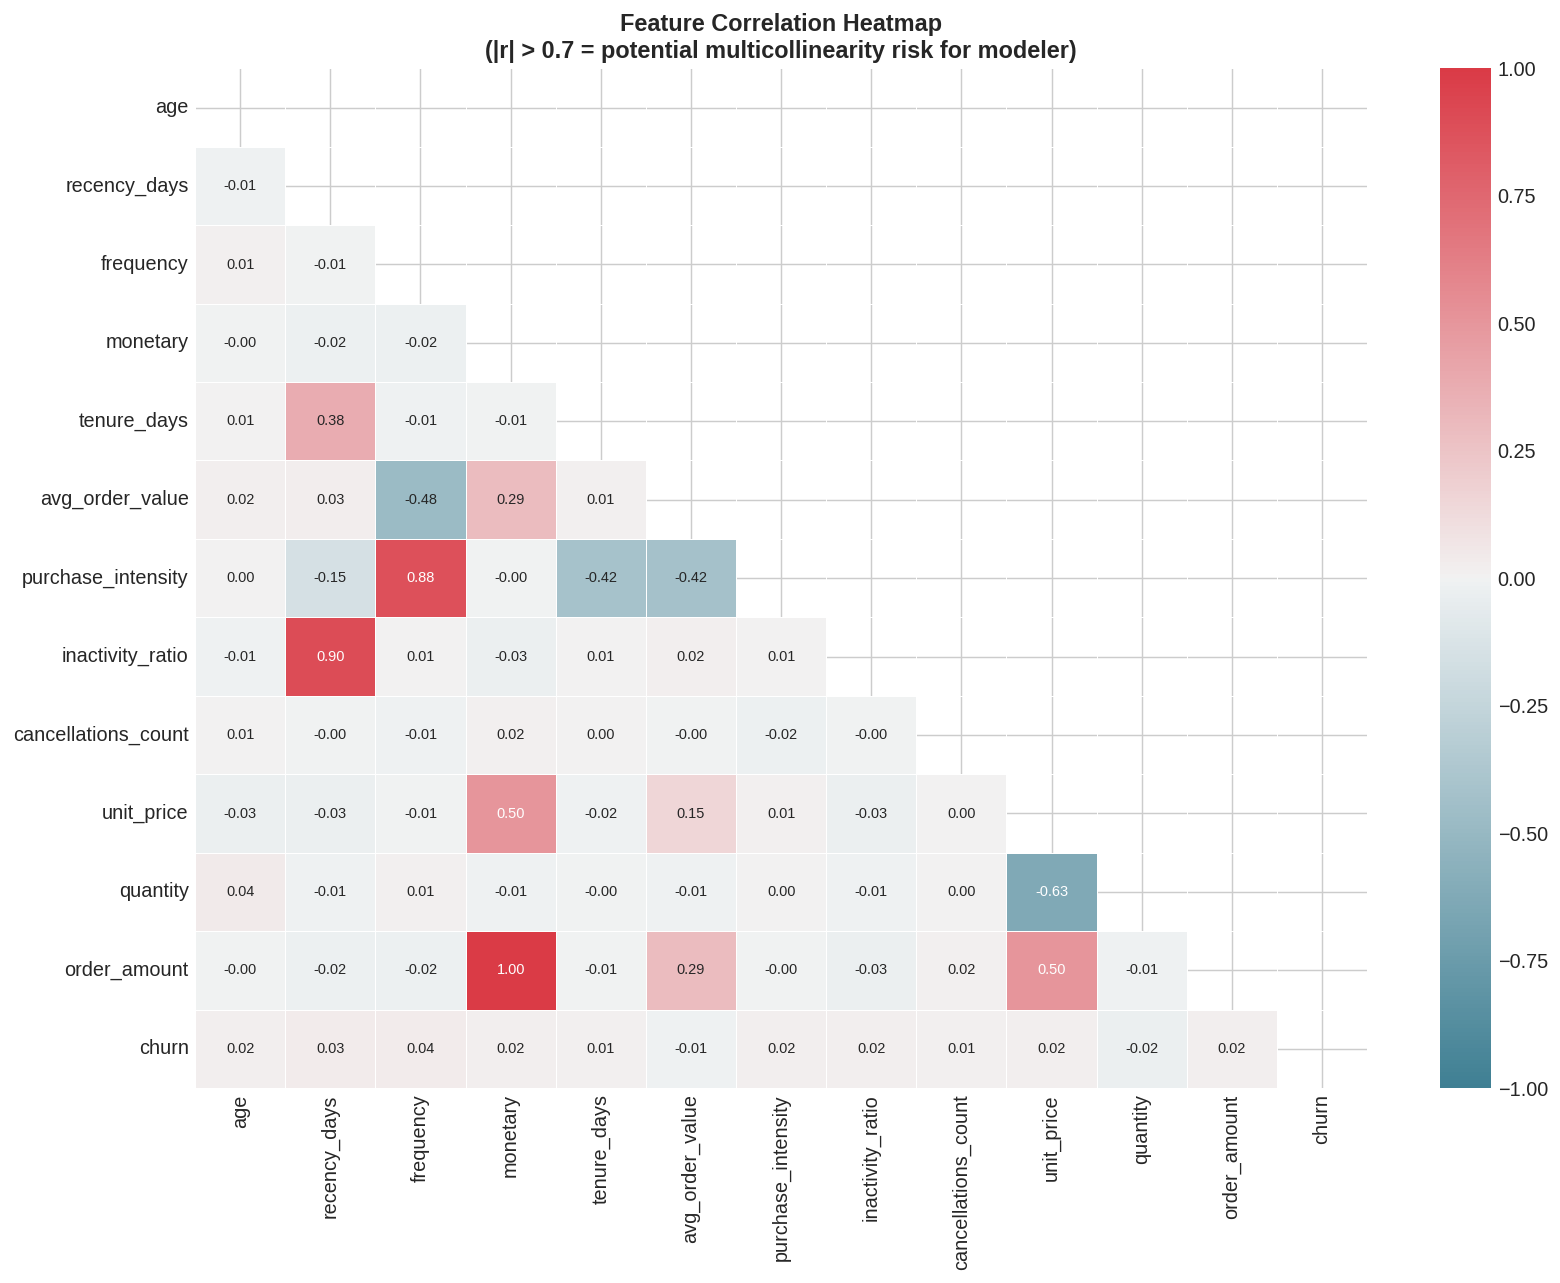

In [24]:
corr_cols = ['age', 'recency_days', 'frequency', 'monetary', 'tenure_days',
             'avg_order_value', 'purchase_intensity', 'inactivity_ratio',
             'cancellations_count', 'unit_price', 'quantity', 'order_amount', 'churn']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', ax=ax,
            cmap=sns.diverging_palette(220, 10, as_cmap=True),
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap\n(|r| > 0.7 = potential multicollinearity risk for modeler)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
threshold = 0.7
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > threshold:
            high_corr.append({
                'Feature A': corr_matrix.columns[i],
                'Feature B': corr_matrix.columns[j],
                'Correlation': round(r, 3)
            })

if high_corr:
    print('Pairs with |r| > 0.7  (flag for modeler — multicollinearity risk):')
    hc_df = pd.DataFrame(high_corr).sort_values('Correlation', key=abs, ascending=False)
    print(hc_df.to_string(index=False))
else:
    print('No pairs exceed |r| = 0.7 threshold — no multicollinearity concerns.')

print('\nFeature correlations with churn (sorted by |r|):')
churn_corr = corr_matrix['churn'].drop('churn').abs().sort_values(ascending=False)
for feat, r in churn_corr.items():
    print(f'  {feat:<25}  |r| = {r:.3f}')

Pairs with |r| > 0.7  (flag for modeler — multicollinearity risk):
   Feature A          Feature B  Correlation
    monetary       order_amount        1.000
recency_days   inactivity_ratio        0.903
   frequency purchase_intensity        0.879

Feature correlations with churn (sorted by |r|):
  frequency                  |r| = 0.037
  recency_days               |r| = 0.035
  quantity                   |r| = 0.024
  inactivity_ratio           |r| = 0.023
  purchase_intensity         |r| = 0.022
  monetary                   |r| = 0.021
  order_amount               |r| = 0.021
  age                        |r| = 0.021
  unit_price                 |r| = 0.018
  cancellations_count        |r| = 0.013
  tenure_days                |r| = 0.012
  avg_order_value            |r| = 0.008


## 11. Class Imbalance Check
The modeler needs to know the class balance before choosing evaluation metrics.

=== Class Balance ===
  Active  (0): 1,507  (75.3%)
  Churned (1): 493  (24.6%)
  Class ratio (Active:Churned) = 3.1 : 1

Moderate class imbalance detected.
  Recommend: class_weight="balanced", SMOTE, and use AUC-ROC / F1 over raw accuracy.


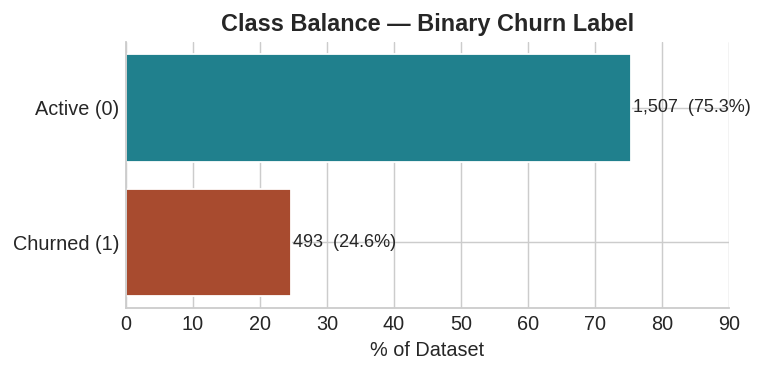

In [26]:
churn_counts = df['churn'].value_counts()
total = len(df)
ratio = churn_counts[0] / churn_counts[1]

print('=== Class Balance ===')
print(f'  Active  (0): {churn_counts[0]:,}  ({churn_counts[0]/total*100:.1f}%)')
print(f'  Churned (1): {churn_counts[1]:,}  ({churn_counts[1]/total*100:.1f}%)')
print(f'  Class ratio (Active:Churned) = {ratio:.1f} : 1')

if ratio > 3:
    print('\nModerate class imbalance detected.')
    print('  Recommend: class_weight="balanced", SMOTE, and use AUC-ROC / F1 over raw accuracy.')
else:
    print('\nClass balance is acceptable. Standard metrics apply.')

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(['Churned (1)', 'Active (0)'],
        [churn_counts[1]/total*100, churn_counts[0]/total*100],
        color=[C_RUST, C_TEAL], edgecolor='white')
for i, (label, v) in enumerate(zip([churn_counts[1], churn_counts[0]],
                                     [churn_counts[1], churn_counts[0]])):
    ax.text(label/total*100 + 0.3, i, f'{label:,}  ({label/total*100:.1f}%)', va='center', fontsize=10)
ax.set_xlabel('% of Dataset')
ax.set_title('Class Balance — Binary Churn Label')
ax.set_xlim(0, 90)
plt.tight_layout()
plt.show()

## 12. Key EDA Takeaways

In [33]:
top_feats = corr_matrix['churn'].drop('churn').abs().sort_values(ascending=False).head(5)

print('=' * 65)
print('EDA SUMMARY — E-COMMERCE CHURN PROJECT')
print('=' * 65)
print(f"""
DATASET
  Rows x Cols  : {df.shape[0]:,} x {df.shape[1]}
  Missing data : None — clean dataset from data engineering team.

TARGET VARIABLE
  Definition   : subscription_status == 'cancelled'  ->  churn = 1
  Churn rate   : {df['churn'].mean()*100:.1f}%  ({df['churn'].sum():,} churned of {len(df):,} customers)
  Class ratio  : {ratio:.1f} : 1  (Active : Churned)
""")

print('TOP PREDICTIVE FEATURES (by |correlation| with churn):')
for feat, r in top_feats.items():
    print(f'  {feat:<25}  |r| = {r:.3f}')

print("""
KEY FINDINGS
  1. Churn is broadly distributed — no single demographic (gender,
     country, age) dominates, but India and Pakistan show slightly
     higher churn rates.
  2. Home category has the highest churn rate among product segments.
  3. Inactivity ratio and recency are the strongest behavioural signals,
     though overall correlations with churn are weak (<0.04).
  4. Prior cancellations count increases churn — each additional
     prior cancellation raises churn probability.
  5. RFM segmentation shows all segments churn at similar rates.
  6. Country x Category heatmap reveals specific high-risk combos
     (e.g. Pakistan Electronics, Canada Home) for targeted campaigns.
""")
print('=' * 65)


EDA SUMMARY — E-COMMERCE CHURN PROJECT

DATASET
  Rows x Cols  : 2,000 x 35
  Missing data : None — clean dataset from data engineering team.

TARGET VARIABLE
  Definition   : subscription_status == 'cancelled'  ->  churn = 1
  Churn rate   : 24.6%  (493 churned of 2,000 customers)
  Class ratio  : 3.1 : 1  (Active : Churned)

TOP PREDICTIVE FEATURES (by |correlation| with churn):
  frequency                  |r| = 0.037
  recency_days               |r| = 0.035
  quantity                   |r| = 0.024
  inactivity_ratio           |r| = 0.023
  purchase_intensity         |r| = 0.022

KEY FINDINGS
  1. Churn is broadly distributed — no single demographic (gender,
     country, age) dominates, but India and Pakistan show slightly
     higher churn rates.
  2. Home category has the highest churn rate among product segments.
  3. Inactivity ratio and recency are the strongest behavioural signals,
     though overall correlations with churn are weak (<0.04).
  4. Prior cancellations count in

## 13. Export

 The final dataset (the churn label, RFM scores, and customer segments).

In [28]:
drop_cols = ['churn_label', 'inactivity_bin', 'recency_bin', 'tenure_bin', 'age_group']
export_cols = [c for c in df.columns if c not in drop_cols]
df_export = df[export_cols].copy()

df_export.to_csv('ecommerce_churn_eda_output.csv', index=False)
print(f'Exported: {df_export.shape[0]:,} rows × {df_export.shape[1]} columns')
print('New columns added:')
new_cols = ['churn', 'R_score', 'F_score', 'M_score', 'RFM_score', 'rfm_segment']
for c in new_cols:
    print(f'  {c}')

from google.colab import files
files.download('ecommerce_churn_eda_output.csv')
print('\nDownload started: ecommerce_churn_eda_output.csv')

Exported: 2,000 rows × 30 columns
New columns added:
  churn
  R_score
  F_score
  M_score
  RFM_score
  rfm_segment


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download started: ecommerce_churn_eda_output.csv
